# Gradient Descent Based Optimization III
# Extensions of Gradient Descent

This article is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20I%20-%20Derivatives%20and%20Partial%20Derivatives.ipynb">Gradient Descent I - Derivatives and Partial Derivatives</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20II%20-%20Gradient%20Descent.ipynb">Gradient Descent II - Gradient Descent</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20III%20-%20Extensions%20of%20GD">Gradient Descent III - Extensions of GD</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20IV%20-%20More%20Extensions%20of%20GD.ipynb">Gradient Descent IV - More Extensions of GD</a>

## Recap

<p>Function optimization can be defined as finding the set of inputs that minimize or maximize an objective function, which in the case of minimization, may be referred to as a cost or loss function. First-order algorithms like gradient descent use the first-order derivatives or partial derivatives to choose which direction to move. Gradient descent begins at a starting point $x$, such as a randomly selected point in the input space, and movements are made by multiplying the learning rate by the gradient, and then subtracting this from the previous point.</p>

<h4>$x_{new} = x - \eta \nabla f(x)$</h4>

# Momentum

<p>Momentum is an extension to gradient descent that builds inertia in a direction of the search space and overcomes the oscillations of noisy gradient.</p>

<p>"The method of momentum is designed to accelerate learning, especially in the face of high curvature, small but consistent gradients, or noisy gradients."</p>
    <ul>
        <li>Deep Learning, Goodfellow, I., Bengio, Y., & Courville, A. (2016)
    </ul>

<p>"An additional hyperparameter controls the amount of history to include in the update equation, and is typically a value close to $1$ like $0.9$. Momentum of $0$ is the same as gradient descent without momentum, and a large momentum will mean the update is strongly influenced by the previous update."</p>
    <ul>
        <li>Optimization for Machine Learning, Jason Brownlee (2021)</li>
    </ul>

## Code - Momentum in One Dimension

In [1]:
# Adapted from Optimization for Machine Learning, Dr. Jason Brownlee
# https://machinelearningmastery.com/optimization-for-machine-learning/

First, we'll import the necessary libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from numpy import meshgrid

Then, create an objective function and derivative function.

In [3]:
def objective(x):
    return x**2 + 4

def d_objective(x):
    return 2*x

Then, create a function similar to the gradient descent function in the last article, but with one more parameter, momentum. An additional variable, change, keeps track of the last movement, and each new change takes that momentum into account.

In [4]:
def grad_descent_momentum(objective, derivative, n_iter, lr, momentum):
    
    solutions = []
    scores = []
    solution = np.random.rand()*-1 + np.random.rand()
    change = 0.0
    
    for i in range(n_iter):
        gradient = d_objective(solution)
        
        new_change = lr * gradient + momentum * change
        solution = solution - new_change
        change = new_change
        
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval)
        
        print('>%d f(%.5f) = %.5f' % (i, solution, solution_eval))
    return solutions, scores

Then, run the function, printing out the scores and solutions at each step.

In [5]:
np.random.seed(7)
n_iter = 30
lr = 0.1
momentum = 0.3

solutions, scores = grad_descent_momentum(objective, d_objective, n_iter, lr, momentum)

>0 f(0.56289) = 4.31684
>1 f(0.40809) = 4.16654
>2 f(0.28004) = 4.07842
>3 f(0.18561) = 4.03445
>4 f(0.12016) = 4.01444
>5 f(0.07650) = 4.00585
>6 f(0.04810) = 4.00231
>7 f(0.02996) = 4.00090
>8 f(0.01852) = 4.00034
>9 f(0.01139) = 4.00013
>10 f(0.00697) = 4.00005
>11 f(0.00425) = 4.00002
>12 f(0.00259) = 4.00001
>13 f(0.00157) = 4.00000
>14 f(0.00095) = 4.00000
>15 f(0.00057) = 4.00000
>16 f(0.00035) = 4.00000
>17 f(0.00021) = 4.00000
>18 f(0.00013) = 4.00000
>19 f(0.00008) = 4.00000
>20 f(0.00005) = 4.00000
>21 f(0.00003) = 4.00000
>22 f(0.00002) = 4.00000
>23 f(0.00001) = 4.00000
>24 f(0.00001) = 4.00000
>25 f(0.00000) = 4.00000
>26 f(0.00000) = 4.00000
>27 f(0.00000) = 4.00000
>28 f(0.00000) = 4.00000
>29 f(0.00000) = 4.00000


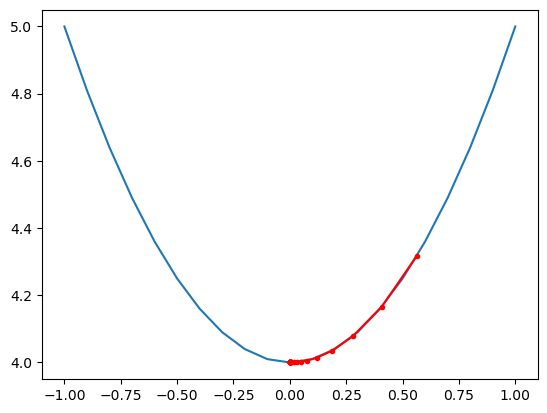

In [6]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

## Code - Momentum in Two Dimensions

With a two-dimensional objective function and derivative function, and some tweaks to our function, we can observe and plot the search in two dimensions.

In [7]:
def objective_2d(x, y): 
    return 2*x**2.0 + 4*y**2.0

def d_objective_2d(x, y):
    return np.asarray([2*x, 2*y])

In [8]:
def grad_descent_momentum_2d(objective, derivative, n_iter, lr, momentum):
    
    solutions = []
    solution = np.random.rand(2)*-1 + np.random.rand(2)
    change = 0.0
    
    for i in range(n_iter):
        gradient = d_objective_2d(solution[0], solution[1])
        
        new_change = lr * gradient + momentum * change
        solution = solution - new_change
        change = new_change
        
        solution_eval = objective(solution[0], solution[1])
        solutions.append(solution)
        print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
    return solutions

In [9]:
# np.random.seed(7)
# n_iter = 30
# lr = 0.1
# momentum = 0.3

solutions = grad_descent_momentum_2d(objective_2d, d_objective_2d, n_iter, lr, momentum)

>0 f([ 0.43166422 -0.14797545]) = 0.46025
>1 f([ 0.31295656 -0.1072822 ]) = 0.24192
>2 f([ 0.21475295 -0.07361778]) = 0.11392
>3 f([ 0.14234128 -0.0487949 ]) = 0.05005
>4 f([ 0.09214952 -0.03158906]) = 0.02097
>5 f([ 0.05866209 -0.02010949]) = 0.00850
>6 f([ 0.03688344 -0.01264372]) = 0.00336
>7 f([ 0.02297316 -0.00787525]) = 0.00130
>8 f([ 0.01420544 -0.00486966]) = 0.00050
>9 f([ 0.00873404 -0.00299405]) = 0.00019
>10 f([ 0.00534581 -0.00183256]) = 0.00007
>11 f([ 0.00326018 -0.0011176 ]) = 0.00003
>12 f([ 0.00198245 -0.00067959]) = 0.00001
>13 f([ 0.00120265 -0.00041227]) = 0.00000
>14 f([ 0.00072817 -0.00024962]) = 0.00000
>15 f([ 0.0004402 -0.0001509]) = 0.00000
>16 f([ 2.65765408e-04 -9.11049666e-05]) = 0.00000
>17 f([ 1.60282579e-04 -5.49452207e-05]) = 0.00000
>18 f([ 9.65812144e-05 -3.31082528e-05]) = 0.00000
>19 f([ 5.81545622e-05 -1.99355119e-05]) = 0.00000
>20 f([ 3.49956541e-05 -1.19965872e-05]) = 0.00000
>21 f([ 2.10488508e-05 -7.21559238e-06]) = 0.00000
>22 f([ 1.26550397

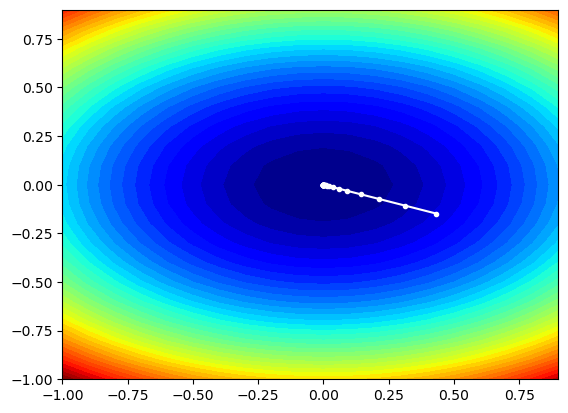

In [10]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

# Adagrad

<p>A problem with gradient descent is that the learning rate is the same for each variable in the dimensions of the search space. AdaGrad is an extension of the gradient descent algorithm that allows the learning rate in each dimension to be automatically adapted. The AdaGrad method adapts a learning rate for each component of $x$, and as such, is suited to objective functions where the curvature of the search space is different in different dimensions.</p>

<p>An internal variable is maintained for each input variable, that is the sum of squared partial derivatives for the input variable. This is then used to calculate the learning rate $\alpha$ for the variable by dividing the initial learning rate $\eta$ by the square root of the sum of partial derivatives.</p>

<h4>$\alpha = \frac{\eta}{\sqrt{S}}$</h4>
    <ul>
        <li>$\alpha$ is the newly calculated learning rate</li>
        <li>$\eta$ is the initial learning rate</li>
        <li>$\sqrt{S}$ is the square root of the partial derivatives</li>
    </ul>

<p>A small constant can be added to the denominator to avoid division by zero. The custom learning rate is then used to calculate the value for the variable at the next point in the search.</p>

<p>$x(t+1) = x(t) - \alpha f'(x(t))$</p>

<p>The process is then repeated for each input variable.</p>


## Code - Adagrad in One Dimension

In [11]:
def adagrad(objective, derivative, n_iter, lr):
    
    solutions = []
    scores = []
    solution = np.array([np.random.rand()*-1 + np.random.rand()])

    sq_grad_sums = [0.0 for _ in range(solution.shape[0])]

    for j in range(n_iter):
        gradient = d_objective(solution)
        
        for i in range(gradient.shape[0]):
            sq_grad_sums[i] += gradient[i]**2.0
            
        new_solution = []
        for i in range(solution.shape[0]):
            alpha = lr / (1e-8 + sqrt(sq_grad_sums[i]))
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)

        solution = np.asarray(new_solution)
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval)

        print('>%d f(%s) = %.5f' % (j, solution, solution_eval))
        
    return solutions, scores

In [12]:
n_iter = 30
lr = 0.1
np.random.seed(7)

solutions, scores = adagrad(objective, d_objective, n_iter, lr)

>0 f([0.6036105]) = 4.36435
>1 f([0.5384993]) = 4.28998
>2 f([0.48827076]) = 4.23841
>3 f([0.44682341]) = 4.19965
>4 f([0.41135961]) = 4.16922
>5 f([0.38032285]) = 4.14465
>6 f([0.35274088]) = 4.12443
>7 f([0.32795733]) = 4.10756
>8 f([0.30550344]) = 4.09333
>9 f([0.28502995]) = 4.08124
>10 f([0.26626771]) = 4.07090
>11 f([0.24900369]) = 4.06200
>12 f([0.23306539]) = 4.05432
>13 f([0.21831055]) = 4.04766
>14 f([0.20461995]) = 4.04187
>15 f([0.19189226]) = 4.03682
>16 f([0.18004039]) = 4.03241
>17 f([0.16898864]) = 4.02856
>18 f([0.15867067]) = 4.02518
>19 f([0.14902783]) = 4.02221
>20 f([0.14000793]) = 4.01960
>21 f([0.13156422]) = 4.01731
>22 f([0.1236546]) = 4.01529
>23 f([0.11624096]) = 4.01351
>24 f([0.10928867]) = 4.01194
>25 f([0.10276611]) = 4.01056
>26 f([0.09664432]) = 4.00934
>27 f([0.09089674]) = 4.00826
>28 f([0.08549885]) = 4.00731
>29 f([0.08042804]) = 4.00647


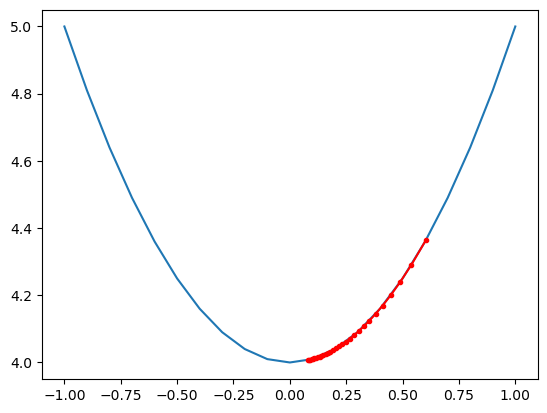

In [13]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

## Code - Adagrad in Two Dimensions

In [14]:
def adagrad_2d(objective, derivative, n_iter, lr):
    
    solutions = []
    solution = np.random.rand(2)*-1 + np.random.rand(2)

    sq_grad_sums = [0.0 for _ in range(solution.shape[0])]

    for j in range(n_iter):
        gradient = derivative(solution[0], solution[1])
        
        for i in range(gradient.shape[0]):
            sq_grad_sums[i] += gradient[i]**2.0
            
        new_solution = []
        for i in range(solution.shape[0]):
            alpha = lr / (1e-8 + sqrt(sq_grad_sums[i]))
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)

        solution = np.asarray(new_solution)
        solutions.append(solution)
        
        solution_eval = objective(solution[0], solution[1])

        print('>%d f(%s) = %.5f' % (j, solution, solution_eval))
        
    return solutions

In [15]:
# n_iter = 30
# lr = 0.1
# np.random.seed(7)

solutions = adagrad_2d(objective_2d, d_objective_2d, n_iter, lr)

>0 f([ 0.43958028 -0.08496931]) = 0.41534
>1 f([ 0.3764197  -0.04322602]) = 0.29086
>2 f([ 0.32884664 -0.02245338]) = 0.21830
>3 f([ 0.29046855 -0.01172549]) = 0.16929
>4 f([ 0.25836389 -0.00613199]) = 0.13365
>5 f([ 0.23090529 -0.00320805]) = 0.10668
>6 f([ 0.20707211 -0.00167853]) = 0.08577
>7 f([ 0.18617098 -0.00087827]) = 0.06932
>8 f([ 0.16770277 -0.00045955]) = 0.05625
>9 f([ 0.15129216 -0.00024045]) = 0.04578
>10 f([ 1.36647039e-01 -1.25816159e-04]) = 0.03734
>11 f([ 1.23533791e-01 -6.58324738e-05]) = 0.03052
>12 f([ 1.11761382e-01 -3.44464083e-05]) = 0.02498
>13 f([ 1.01170747e-01 -1.80238565e-05]) = 0.02047
>14 f([ 9.16274491e-02 -9.43086434e-06]) = 0.01679
>15 f([ 8.30164609e-02 -4.93463773e-06]) = 0.01378
>16 f([ 7.52383541e-02 -2.58201674e-06]) = 0.01132
>17 f([ 6.82064559e-02 -1.35102327e-06]) = 0.00930
>18 f([ 6.18446833e-02 -7.06914042e-07]) = 0.00765
>19 f([ 5.60858609e-02 -3.69888123e-07]) = 0.00629
>20 f([ 5.08703935e-02 -1.93541527e-07]) = 0.00518
>21 f([ 4.61452003e

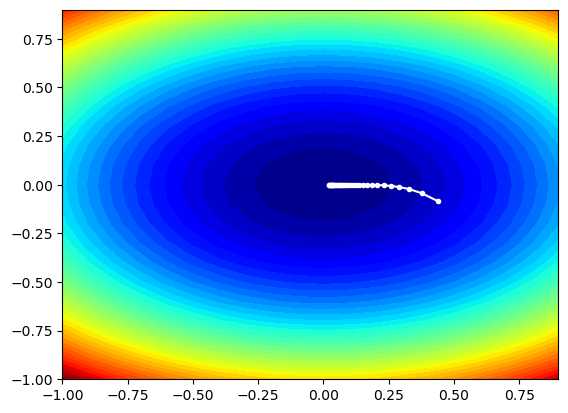

In [16]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

## RMSProp

<p>A limitation of AdaGrad is that it can result in a very small learning rate for each parameter by the end of the search, which may have the effect of stopping too soon. RMSProp extends AdaGrad to avoid the effect of a monotonically decreasing learning rate. It uses a decaying moving average of partial derivatives instead of the sum in the calculation of the learning rate for each parameter.</p>

<p>This is accomplished by adding a hyperparameter $\rho$ that acts like momentum. Using a decaying moving average of the partial derivative allows the search to forget early partial derivative values and focus on more recent ones.</p>

<p>The calculation of the mean squared partial derivative for one parameter is as follows:</p>

<p>$s(t+1) = s(t) \times \rho + f'(x(t))^2 \times (1 - \rho)$</p>
    <ul>
        <li>$s(t+1)$ is the decaying moving average of the squared partial derivative for one parameter for the current iteration of the algorithm</li>
        <li>$s(t)$ is the decaying moving average of squared partial derivatives for the previous iteration</li>
        <li>$f'(x(t))^2$ is the squared partial derivative for the current parameter</li>
        <li>$\rho$ is a parameter typically set to a value like $0.9$</li>
    </ul>

<p>With the initial learning rate as $\eta$, the custom learning rate $\alpha$ for a parameter can be written as:</p>

<h4>$\alpha(t+1) = \frac{\eta}{\sqrt{s(t+1)} + \epsilon}$</h4>

<p>Once we have the custom learning rate for the parameter, we can update the parameter using the custom learning rate and the partial derivative $f'(x(t))$.</p>

<p>$x(t+1) = x(t) - \alpha(t+1) f'(x(t))$</p>

## Code - RMSProp in One Dimension

In [17]:
def rmsprop(objective, derivative, n_iter, lr, rho):

    solutions = []
    scores = []
    solution = np.array([np.random.rand()*-1 + np.random.rand()])
    sq_grad_avg = [0]
    
    for it in range(n_iter):
        
        gradient = derivative(solution)
        
        for i in range(gradient.shape[0]):
            sg = gradient[i]**2.0
            sq_grad_avg[i] = (sq_grad_avg[i] * rho) + (sg * (1.0-rho))

        new_solution = []
        for i in range(solution.shape[0]):
            alpha = lr / (1e-8 + sqrt(sq_grad_avg[i]))
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)
        solution = np.asarray(new_solution)
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval)
        print('>%d f(%s) = %.5f' % (it, solution, solution_eval))
    return solutions, scores

In [18]:
np.random.seed(7)
n_iter = 30
lr = 0.01
rho = 0.99

solutions, scores = rmsprop(objective, d_objective, n_iter, lr, rho)

>0 f([0.60361051]) = 4.36435
>1 f([0.53831096]) = 4.28978
>2 f([0.48779809]) = 4.23795
>3 f([0.44600487]) = 4.19892
>4 f([0.41015295]) = 4.16823
>5 f([0.37869875]) = 4.14341
>6 f([0.35067959]) = 4.12298
>7 f([0.32544661]) = 4.10592
>8 f([0.30253722]) = 4.09153
>9 f([0.28160729]) = 4.07930
>10 f([0.26239204]) = 4.06885
>11 f([0.24468217]) = 4.05987
>12 f([0.22830841]) = 4.05212
>13 f([0.21313127]) = 4.04542
>14 f([0.19903389]) = 4.03961
>15 f([0.18591695]) = 4.03457
>16 f([0.17369506]) = 4.03017
>17 f([0.16229392]) = 4.02634
>18 f([0.15164831]) = 4.02300
>19 f([0.14170047]) = 4.02008
>20 f([0.13239887]) = 4.01753
>21 f([0.1236972]) = 4.01530
>22 f([0.11555361]) = 4.01335
>23 f([0.10793007]) = 4.01165
>24 f([0.10079188]) = 4.01016
>25 f([0.09410719]) = 4.00886
>26 f([0.0878467]) = 4.00772
>27 f([0.08198336]) = 4.00672
>28 f([0.07649209]) = 4.00585
>29 f([0.07134964]) = 4.00509


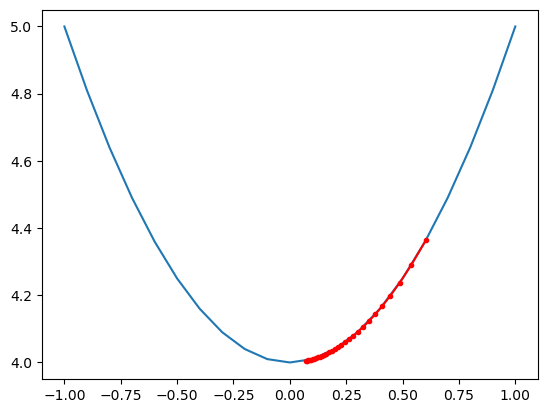

In [19]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

## Code - RMSProp in Two Dimensions

In [20]:
def rmsprop_2d(objective, derivative, n_iter, step_size, rho):

    solutions = []
    solution = np.random.rand(2)*-1 + np.random.rand(2)
    sq_grad_avg = [0.0 for _ in range(len(solution))]
    
    for j in range(n_iter):
        gradient = derivative(solution[0], solution[1])
        
        for i in range(gradient.shape[0]):
            sg = gradient[i]**2.0
            sq_grad_avg[i] = (sq_grad_avg[i] * rho) + (sg * (1.0-rho))

        new_solution = []
        for i in range(solution.shape[0]):
            alpha = step_size / (1e-8 + sqrt(sq_grad_avg[i]))
            value = solution[i] - alpha * gradient[i]
            new_solution.append(value)
        solution = np.asarray(new_solution)
        solutions.append(solution)
        solution_eval = objective(solution[0], solution[1])
        print('>%d f(%s) = %.5f' % (j, solution, solution_eval))
    return solutions

In [21]:
# np.random.seed(7)
# n_iter = 30
# lr = 0.01
# rho = 0.99

solutions = rmsprop_2d(objective_2d, d_objective_2d, n_iter, lr, rho)

>0 f([ 0.43958029 -0.08496933]) = 0.41534
>1 f([ 0.37622903 -0.04305262]) = 0.29051
>2 f([ 0.32837838 -0.02217737]) = 0.21763
>3 f([ 0.28967459 -0.01143245]) = 0.16835
>4 f([ 0.2572182  -0.00587414]) = 0.13246
>5 f([ 0.22939674 -0.003005  ]) = 0.10528
>6 f([ 0.20520052 -0.00153002]) = 0.08422
>7 f([ 0.18394452 -0.00077526]) = 0.06767
>8 f([ 0.16513614 -0.0003909 ]) = 0.05454
>9 f([ 0.14840507 -0.00019612]) = 0.04405
>10 f([ 1.33463035e-01 -9.79061201e-05]) = 0.03562
>11 f([ 1.20079234e-01 -4.86287613e-05]) = 0.02884
>12 f([ 1.08064577e-01 -2.40300034e-05]) = 0.02336
>13 f([ 9.72611899e-02 -1.18132389e-05]) = 0.01892
>14 f([ 8.75351809e-02 -5.77717598e-06]) = 0.01532
>15 f([ 7.87715120e-02 -2.81041355e-06]) = 0.01241
>16 f([ 7.08702763e-02 -1.35990663e-06]) = 0.01005
>17 f([ 6.37439323e-02 -6.54497512e-07]) = 0.00813
>18 f([ 5.73152108e-02 -3.13287018e-07]) = 0.00657
>19 f([ 5.15154990e-02 -1.49137663e-07]) = 0.00531
>20 f([ 4.62835727e-02 -7.06020718e-08]) = 0.00428
>21 f([ 4.15645845e

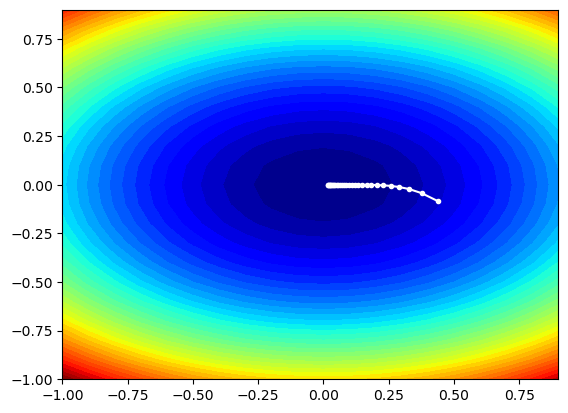

In [22]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

<p>The next article, with additional extensions of gradient descent, can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20IV%20-%20More%20Extensions%20of%20GD.ipynb">here</a></p>

# References

- Duchi, J., Hazan, E., & Singer, Y. (2011). Adaptive Subgradient Methods for Online Learning and Stochastic Optimization. Journal of Machine Learning Research.
https://arxiv.org/abs/1212.5701

- Brownlee, J. (2021). Optimization for Machine Learning (A. Tam, Ed.) (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/optimization-for-machine-learning/

- Cristina, S., Saeed, M., & Tam, A. (2022). Calculus for Machine Learning (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/calculus-for-machine-learning/

- Cohen, M. X. (2024). Master calculus 1 using Python: Derivatives and applications [Online Video]. Udemy. https://www.udemy.com/course/pycalc1_x

- Cohen, M. X. (2024). A deep understanding of deep learning [Online Video]. Udemy. https://www.udemy.com/course/deeplearning_x

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. 
https://www.deeplearningbook.org/